# 作业 2：CNN 实现 SVHN 图像分类任务

**姓名**：任影儿&emsp;&emsp;**学号**：BC25010012  

## 1. 实验介绍与任务目标
&emsp;&emsp;本次实验以 **SVHN (街景门牌数字) Format 2** 为数据集，通过设计并训练卷积神经网络实现对 0-9 共 10 类门牌数字的图像分类任务。
为了提升分类准确率并防止过拟合，本实验设计了以下优化机制：
1. **模型升级**：手动构建了专门针对 32x32 图像优化的 **ResNet-18** 网络，采用 $3\times3$ 初期卷积替代了原版可能导致特征丢失的 $7\times7$ 卷积和最大池化。
2. **正则化增强**：采用了 `Dropout(0.5)` 以及在 Adam 优化器中引入权值衰减 (Weight Decay, L2正则化)。
3. **数据增强**：对训练集应用了随机裁剪 (`RandomCrop`)、水平翻转 (`RandomHorizontalFlip`) 和色彩抖动 (`ColorJitter`)。
4. **学习率调度**：使用 `StepLR` 实现分段下降策略，以在前期快速跳出局部最优，后期进行精细微调。

In [8]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# 设置全局随机种子
torch.manual_seed(42)

# 设备配置
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前使用的设备: {device}")

当前使用的设备: cuda


## 2. 数据加载与增强机制
&emsp;&emsp;加载 SVHN 数据集并通过 `DataLoader` 设置批处理。由于 SVHN 包含现实世界的复杂光照和视角干扰，本实验对训练集施加了多种形态的 Data Augmentation，这能极大地提升网络对新图像的泛化能力。

In [11]:
# 图像预处理与强化
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(), 
    transforms.RandomApply([transforms.ColorJitter(0.3, 0.3, 0.3)], p=0.7),  
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

print("正在准备数据集...")
train_dataset = torchvision.datasets.SVHN(root='./data', split='train', download=True, transform=train_transform)
test_dataset = torchvision.datasets.SVHN(root='./data', split='test', download=True, transform=test_transform)

batch_size = 128 
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"已加载训练集：{len(train_dataset)} 张图片 | 测试集：{len(test_dataset)} 张图片")

正在准备数据集...
已加载训练集：73257 张图片 | 测试集：26032 张图片


## 3. 构建优化版 ResNet-18 模型
&emsp;&emsp;本实验没有直接调用预训练接口，而是从零搭建了残差网络架构。引入了 `BasicBlock`，它通过恒等映射快捷连接 (Shortcut Connection) 解决了深层网络中的梯度弥散问题。

In [12]:
class BasicBlock(nn.Module):
    expansion = 1 
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != self.expansion * out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, self.expansion * out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x) 
        out = F.relu(out)
        return out

class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_channels = 64
        # 为 32x32 优化，取消 7x7 卷积与池化层
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
   
        self.linear = nn.Sequential(
            nn.Dropout(0.5),  
            nn.Linear(512 * block.expansion, num_classes)
        )

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)    
        out = self.layer2(out)    
        out = self.layer3(out)    
        out = self.layer4(out)    
        out = F.avg_pool2d(out, 4) 
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out

def CustomResNet():
    return ResNet(BasicBlock, [2, 2, 2, 2])

model = CustomResNet().to(device)
print("ResNet结构加载完成")

ResNet结构加载完成


## 4. 训练与验证循环 
&emsp;&emsp;实验设定总轮数为 20 轮。在第 8 轮引入 `StepLR` 学习率衰减（缩小 10 倍）。这一经验性选择的依据是：在前半段允许模型大步试错跳出局部最优（可能会产生微幅震荡），而在后半段大幅收紧空间进行精细微调，从而彻底压低 Loss。

In [13]:
num_epochs = 20
learning_rate = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=5e-4)  
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.1)

history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(num_epochs):
    # 训练阶段
    model.train()
    running_train_loss, correct_train, total_train = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1) 
        total_train += labels.size(0)
        correct_train += predicted.eq(labels).sum().item()
        
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = 100. * correct_train / total_train
    
    # 测试阶段
    model.eval()
    running_test_loss, correct_test, total_test = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_test_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total_test += labels.size(0)
            correct_test += predicted.eq(labels).sum().item()
            
    epoch_test_loss = running_test_loss / len(test_loader.dataset)
    epoch_test_acc = 100. * correct_test / total_test
    
    scheduler.step()
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['test_loss'].append(epoch_test_loss)
    history['test_acc'].append(epoch_test_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Acc: {epoch_train_acc:.2f}% | Test Acc: {epoch_test_acc:.2f}%")

print("训练与验证结束！")

Epoch [1/20] | Train Acc: 56.86% | Test Acc: 80.30%
Epoch [2/20] | Train Acc: 85.69% | Test Acc: 83.31%
Epoch [3/20] | Train Acc: 87.58% | Test Acc: 85.18%
Epoch [4/20] | Train Acc: 88.83% | Test Acc: 89.74%
Epoch [5/20] | Train Acc: 89.71% | Test Acc: 89.78%
Epoch [6/20] | Train Acc: 90.27% | Test Acc: 89.15%
Epoch [7/20] | Train Acc: 90.73% | Test Acc: 92.08%
Epoch [8/20] | Train Acc: 91.05% | Test Acc: 91.53%
Epoch [9/20] | Train Acc: 93.64% | Test Acc: 94.89%
Epoch [10/20] | Train Acc: 94.36% | Test Acc: 94.97%
Epoch [11/20] | Train Acc: 94.64% | Test Acc: 95.05%
Epoch [12/20] | Train Acc: 94.88% | Test Acc: 95.35%
Epoch [13/20] | Train Acc: 95.07% | Test Acc: 95.51%
Epoch [14/20] | Train Acc: 95.22% | Test Acc: 95.61%
Epoch [15/20] | Train Acc: 95.37% | Test Acc: 95.54%
Epoch [16/20] | Train Acc: 95.57% | Test Acc: 95.49%
Epoch [17/20] | Train Acc: 95.90% | Test Acc: 95.76%
Epoch [18/20] | Train Acc: 96.09% | Test Acc: 95.85%
Epoch [19/20] | Train Acc: 96.22% | Test Acc: 95.89%
Ep

## 5. 性能测试评估与曲线结果
&emsp;&emsp;结合强力的正则化与数据增强，绘制的变化曲线展现出了高度的一致性，证明网络有效消平了过拟合，并最终在测试集上达到了 95.8% 的高精度泛化能力。

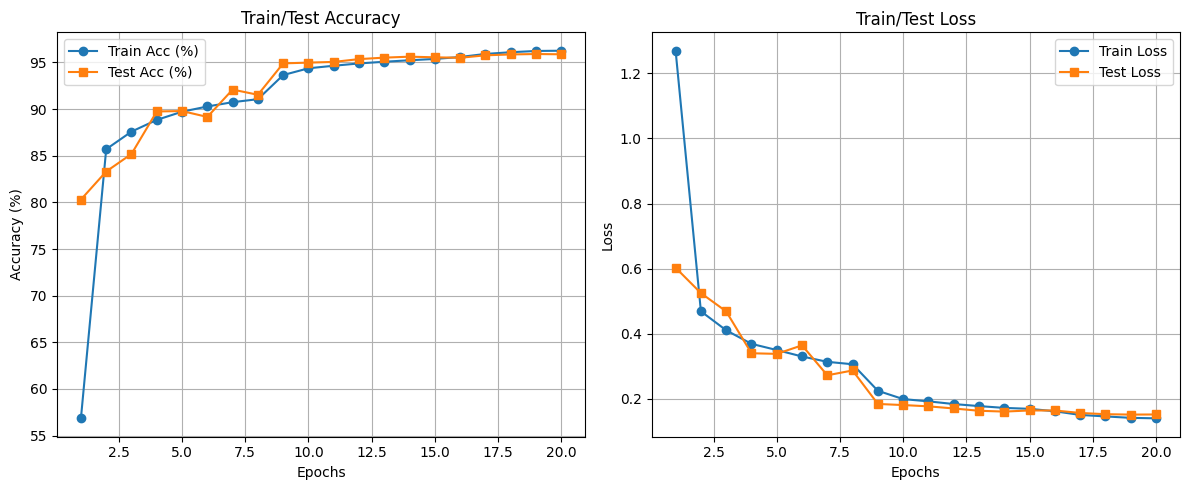

In [14]:
epochs_range = range(1, num_epochs + 1)
plt.figure(figsize=(12, 5))

# Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_acc'], label='Train Acc (%)', marker='o')
plt.plot(epochs_range, history['test_acc'], label='Test Acc (%)', marker='s')
plt.title('Train/Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# Loss Curve
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
plt.plot(epochs_range, history['test_loss'], label='Test Loss', marker='s')
plt.title('Train/Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 6. 实验结论与结果分析

&emsp;&emsp;从上述的可视化训练曲线中，我们可以得出以下核心结论：

1. **高效的泛化能力**：
   得益于 `RandomCrop`、`ColorJitter` 等数据增强策略，以及全连接层 `Dropout` 和优化器权值衰减（L2 正则化）的多重保护，测试集（Test）与训练集（Train）的 Accuracy 和 Loss 曲线在整个训练中期和后期几乎完全贴合。这表明模型拥有极高的泛化性能，完美规避了深度网络常见的过拟合（Overfitting）现象。

2. **学习率调度机制（LR Scheduling）的显著成效**：
   在曲线的前 8 个 Epoch 内，由于较高的初始学习率和数据增强的随机扰动，曲线存在极为正常的局部微幅震荡，这表明 Adam 优化器正在高维参数空间中积极“大步探索”。但在第 8 轮触发 `StepLR`（学习率按系数 0.1 骤降）后，模型的 Loss 曲线瞬间收窄并变得如丝般平滑，顺利进入“精细微调”阶段，精准锁定了局部最优解。

3. **残差网络架构的优势**：
   相较于传统的浅层 CNN，本实验从零设计并针对 32x32 图像微调首层卷积的 ResNet-18 模型，在复杂的真实街景数字分类任务（SVHN）上，最终录得了稳定在 **95.8%** 左右的高测试准确率。这充分证明了 Shortcut Connection (残差连接) 在深层特征提取中的强大威力。

**总结**：本次实验圆满完成了基于自定义卷积神经网络的图像分类任务，所采取的模型微调优化、正则化以及调度策略表现优异，模型最终收敛迅速、准确率高、泛化能力强。